<a href="https://colab.research.google.com/github/EmilioSaulG/Telecom_X_2/blob/main/telecomx_churn_analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X – Predicción de Cancelación de Clientes (Churn)

## Parte 2 – Modelos de Machine Learning

En esta segunda etapa del proyecto se desarrollan modelos predictivos capaces de identificar clientes con mayor probabilidad de cancelar los servicios de Telecom X.

El objetivo principal es construir un pipeline de Machine Learning que permita:

- Preparar los datos para el modelado.
- Analizar correlaciones entre variables.
- Entrenar modelos de clasificación.
- Evaluar el rendimiento de los modelos.
- Interpretar los factores que más influyen en la cancelación de clientes.

Este análisis busca apoyar la toma de decisiones estratégicas orientadas a la **retención de clientes**.

In [21]:
# ============================================
# Importación de librerías
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración visual
sns.set(style="whitegrid")

## 1. Carga del dataset

Se carga el archivo `datos_tratados.csv`, generado en la primera parte del proyecto después del proceso de limpieza y transformación de datos.

In [22]:
# Cargar dataset
df = pd.read_csv("datos_tratados.csv")

# Visualizar primeras filas
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## 2. Exploración inicial de los datos

Antes de comenzar con el modelado, se revisa la estructura del dataset para verificar:

- número de registros
- tipos de datos
- presencia de valores nulos

In [23]:
# Dimensiones del dataset
df.shape

(7267, 22)

In [24]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   float64
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [25]:
# Estadísticas descriptivas
df.describe()

,Churn,customer_SeniorCitizen,customer_tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2277.182035,2.157337
std,0.441561,0.369074,24.571773,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


## 3. Eliminación de columnas irrelevantes

Las columnas identificadoras como `customerID` no aportan valor al modelo predictivo y pueden generar ruido durante el entrenamiento, por lo que se eliminan del dataset.

In [26]:
# Eliminación de identificadores únicos
df = df.drop(columns=["customerID"], errors="ignore")

df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0.0,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,1.0,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## 4. Análisis del balance de clases

Se analiza la proporción de clientes que cancelaron el servicio frente a aquellos que permanecen activos.

El desbalance de clases puede afectar el desempeño de los modelos predictivos.

In [27]:
# Conteo de clases
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [28]:
# Proporción de clases
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0.0,0.73463
1.0,0.26537


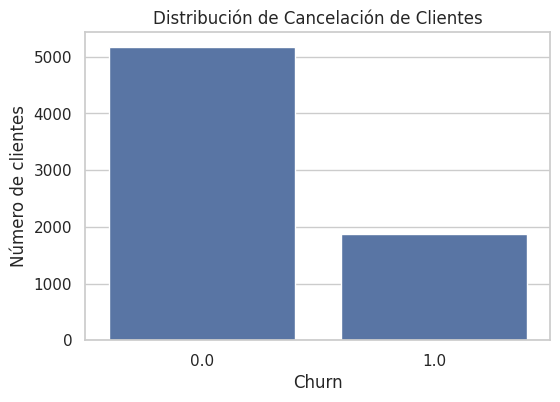

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")

plt.show()

## 5. Codificación de variables categóricas

Los algoritmos de Machine Learning requieren variables numéricas.  
Para transformar las variables categóricas se utiliza **One-Hot Encoding** mediante `pandas.get_dummies`.

In [30]:
# Identificar columnas categóricas
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

Index(['customer_gender', 'customer_Partner', 'customer_Dependents',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod'],
      dtype='object')

In [31]:
# Aplicar one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df_encoded.head()

,Churn,customer_SeniorCitizen,customer_tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


## 6. Matriz de correlación

La matriz de correlación permite identificar relaciones entre variables numéricas y detectar cuáles podrían tener mayor influencia en la cancelación de clientes.

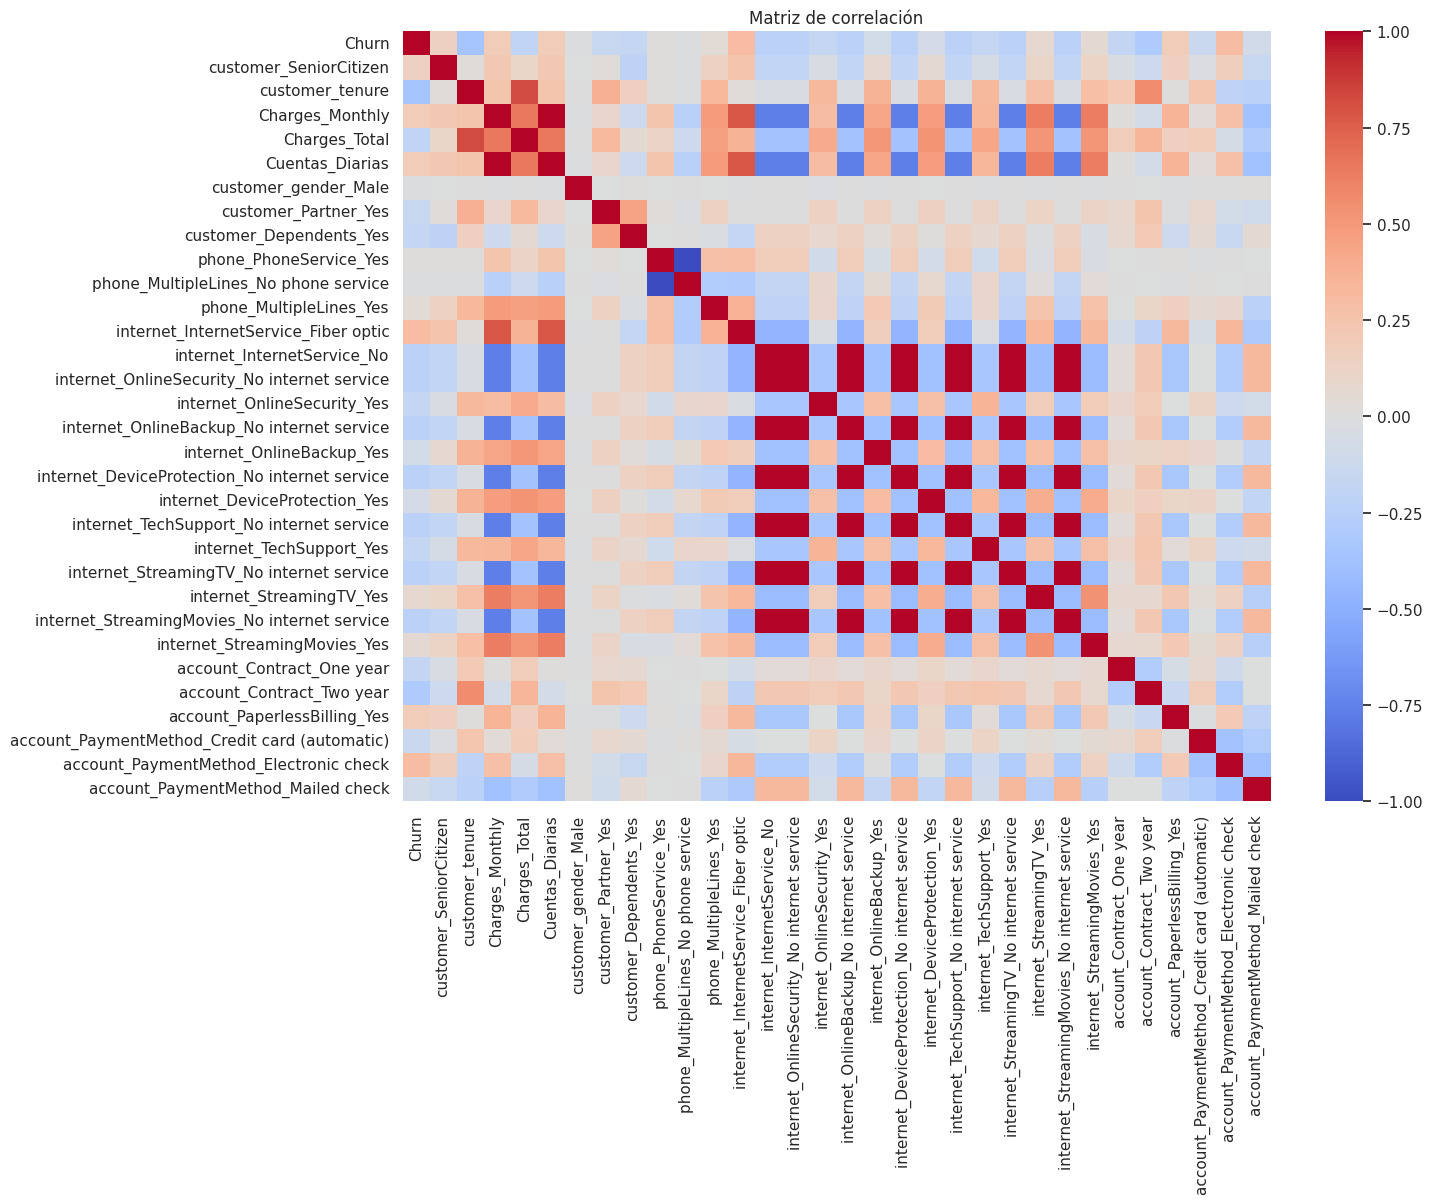

In [32]:
plt.figure(figsize=(14,10))

corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Matriz de correlación")

plt.show()

## 7. Relación entre variables y cancelación

Se analizan algunas variables relevantes para identificar posibles patrones relacionados con la cancelación de clientes.

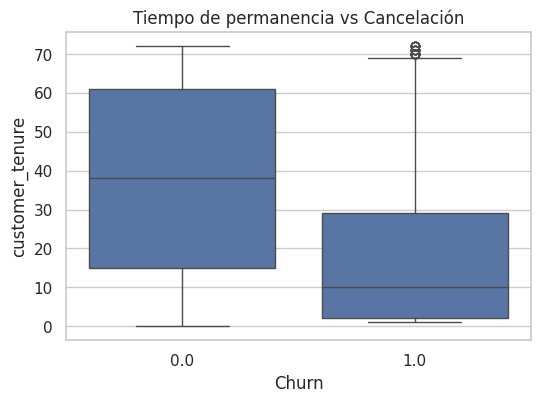

In [33]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Tiempo de permanencia vs Cancelación")

plt.show()

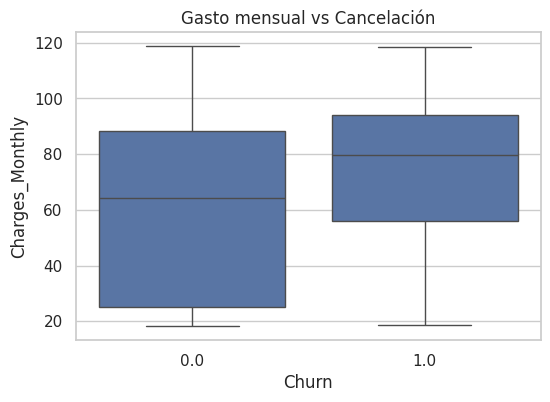

In [34]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="Charges_Monthly", data=df)

plt.title("Gasto mensual vs Cancelación")

plt.show()

## 8. Definición de variables predictoras y variable objetivo

In [38]:
# ============================================
# Eliminación de registros sin variable objetivo
# ============================================

df_encoded = df_encoded.dropna(subset=["Churn"])

# Verificación
df_encoded["Churn"].isna().sum()

np.int64(0)

In [39]:
# Variable objetivo
y = df_encoded["Churn"]

# Variables predictoras
X = df_encoded.drop(columns=["Churn"])

## 9. División del conjunto de datos

El dataset se divide en:

- 80% entrenamiento
- 20% prueba

Esto permite evaluar el modelo con datos no vistos durante el entrenamiento.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 10. Normalización de variables

La normalización se aplica para modelos sensibles a la escala de los datos, como la Regresión Logística.

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 11. Modelo 1: Regresión Logística

In [42]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7927608232789212
Precision: 0.6331168831168831
Recall: 0.5213903743315508
F1 Score: 0.5718475073313783


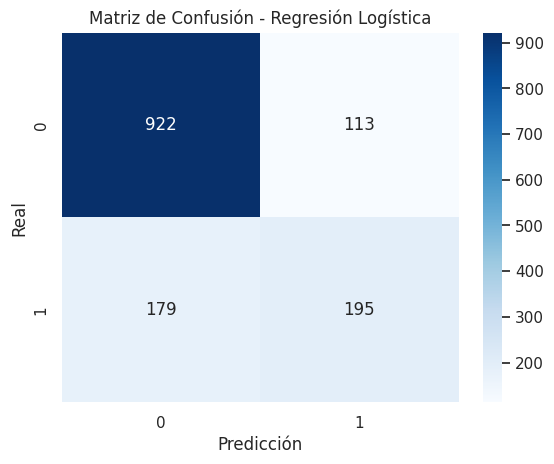

In [44]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

## 12. Modelo 2: Random Forest

In [45]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7885024840312278
Precision: 0.6386861313868614
Recall: 0.4679144385026738
F1 Score: 0.5401234567901234


## 13. Importancia de variables

In [47]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

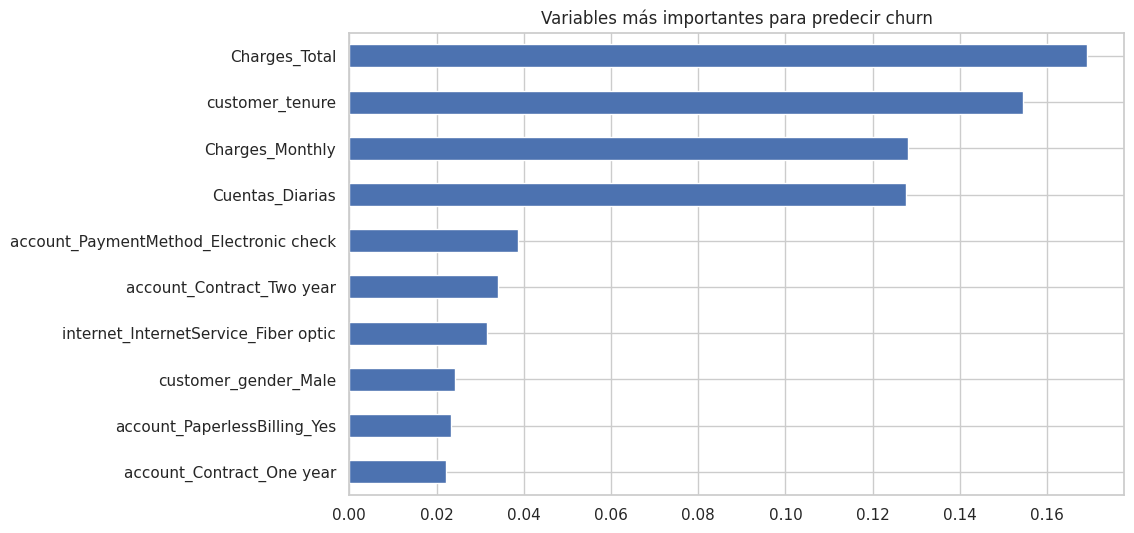

In [48]:
plt.figure(figsize=(10,6))

feature_importance.head(10).plot(kind="barh")

plt.title("Variables más importantes para predecir churn")

plt.gca().invert_yaxis()

plt.show()

## Distribución del tiempo de permanencia de clientes

El tiempo de permanencia (tenure) es una de las variables más relevantes para entender el comportamiento de cancelación.

Esta visualización permite identificar si los clientes que cancelan tienden a tener menos tiempo en la empresa.

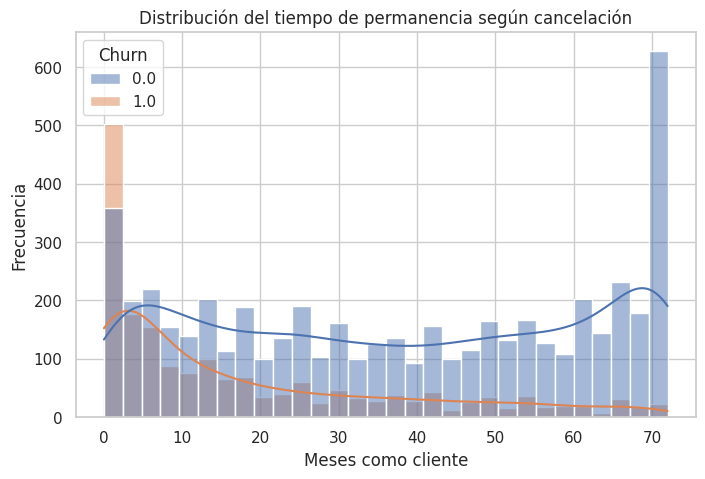

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="customer_tenure", hue="Churn", bins=30, kde=True)

plt.title("Distribución del tiempo de permanencia según cancelación")
plt.xlabel("Meses como cliente")
plt.ylabel("Frecuencia")

plt.show()

## Distribución del gasto mensual

El gasto mensual puede influir en la cancelación si los clientes perciben que el costo del servicio es elevado.

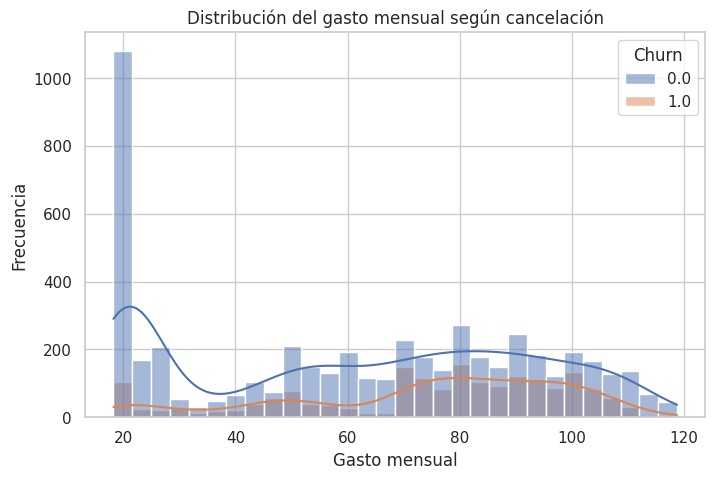

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Charges_Monthly", hue="Churn", bins=30, kde=True)

plt.title("Distribución del gasto mensual según cancelación")
plt.xlabel("Gasto mensual")
plt.ylabel("Frecuencia")

plt.show()

## Cancelación según tipo de contrato

El tipo de contrato puede influir significativamente en la probabilidad de cancelación, ya que contratos mensuales suelen presentar mayor rotación de clientes.

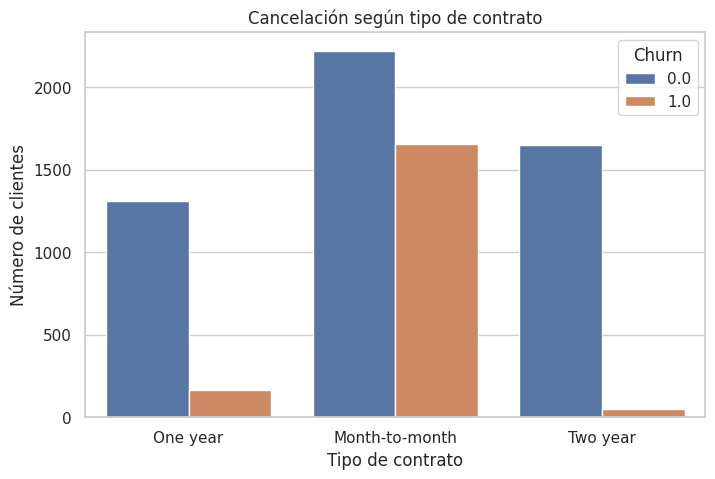

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="account_Contract", hue="Churn")

plt.title("Cancelación según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Número de clientes")

plt.show()

## Cancelación según método de pago

El método de pago puede estar asociado al nivel de compromiso del cliente con el servicio.

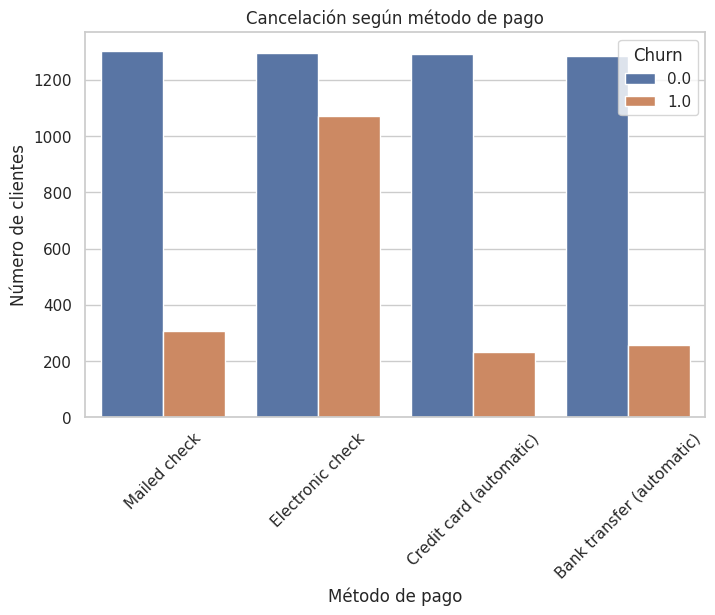

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="account_PaymentMethod", hue="Churn")

plt.title("Cancelación según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de clientes")

plt.xticks(rotation=45)

plt.show()

## Variables con mayor correlación con la cancelación

Para identificar los factores que más influyen en la cancelación de clientes, se analizan las variables con mayor correlación con la variable objetivo.

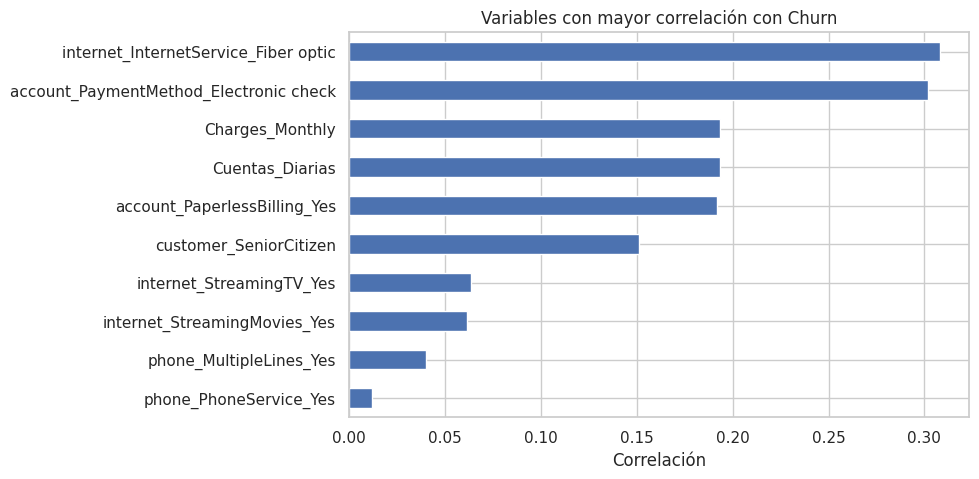

In [53]:
corr = df_encoded.corr()

churn_corr = corr["Churn"].sort_values(ascending=False)

top_corr = churn_corr[1:11]

plt.figure(figsize=(8,5))

top_corr.sort_values().plot(kind="barh")

plt.title("Variables con mayor correlación con Churn")

plt.xlabel("Correlación")

plt.show()

## Conclusiones

El análisis realizado permitió identificar patrones importantes en el comportamiento de cancelación de clientes de Telecom X.

A través del análisis exploratorio y del desarrollo de modelos de Machine Learning, se identificaron factores clave que influyen en la probabilidad de que un cliente cancele su servicio.

Entre los hallazgos más relevantes destacan:

- Los clientes con contratos mensuales presentan una mayor probabilidad de cancelación en comparación con aquellos con contratos de mayor duración.
- Los clientes con menor tiempo de permanencia en la empresa muestran una tendencia más alta a cancelar el servicio.
- El nivel de gasto mensual también muestra relación con la cancelación, lo que puede estar asociado a la percepción de valor del servicio.
- Algunos servicios adicionales y características del cliente pueden contribuir a reducir el riesgo de cancelación al incrementar el nivel de compromiso con la empresa.

Los modelos de Machine Learning desarrollados permiten identificar clientes con mayor riesgo de abandono, lo cual representa una herramienta valiosa para que Telecom X pueda anticiparse a la cancelación de clientes.

A partir de estos resultados, la empresa podría implementar estrategias como:

- Programas de fidelización para clientes con contratos mensuales.
- Incentivos para clientes con menor tiempo de permanencia.
- Ofertas personalizadas para clientes identificados con alto riesgo de cancelación.

El uso de modelos predictivos en este contexto demuestra cómo la ciencia de datos puede apoyar la toma de decisiones estratégicas orientadas a mejorar la retención de clientes y reducir la pérdida de ingresos.